# **📊 Pr. 1**

---

**Title:** Predictive Insight Engine

**Duration:** 6 Hours

---

## **🎯 Objective**

The objective of this project is to evaluate students' understanding of advanced supervised learning regression techniques, with a strong focus on regularization, model generalization, cross-validation strategies, and tree-based regression algorithms. Students will learn how to control overfitting, select optimal models, and compare linear vs non-linear regressors using real-world data.

---

## **📑 Problem Statement**

You are working as a **Machine Learning Engineer** at a real estate analytics company. The company already uses a basic regression model to predict **house prices**, but it suffers from **overfitting and unstable predictions** across different datasets.

Your task is to build a **robust regression pipeline** that:

- Applies **regularization techniques**
- Uses **proper cross-validation strategies**
- Compares **linear and non-linear regression models**
- Selects the **best-performing model** based on validation performance

The final solution must generalize well on unseen data.

---

## **📚 Download and Import Modules**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

---

## **🧠 Part A: Conceptual Foundation (Theory)**

Answer briefly (2–4 lines each):

1. What is **Regularization** in Machine Learning? Why is it needed?
2. Difference between **Ridge Regression (L2)** and **Lasso Regression (L1)**.
3. What is **Cross-Validation** and why is it important?
4. Explain the following cross-validation techniques:
    - K-Fold Cross-Validation
    - Stratified K-Fold Cross-Validation
    - Leave-One-Out Cross-Validation (LOOCV)
    - Time Series Split
5. Why are **tree-based models** less sensitive to feature scaling?

Questions & Answers are written in the file named [`theory-concepts.pdf`](./theory-concepts.pdf) in the main directory.

---

## **🧪 Part B: Dataset Understanding & Preparation**

You are provided with a **real estate dataset** containing:

* Property size and structural attributes
* Location-based numerical indicators
* Property age and renovation details
* Target variable: **House Price**

**Dataset:** [Access from here](./data/Advanced_Regression_HousePrice_Dataset_3800.csv)

**Tasks:**

6. Identify **features and target variable**.
7. Perform a **train–test split**.
8. Apply **basic preprocessing** (scaling where required).

In [2]:
data_path = r".\data\Advanced_Regression_HousePrice_Dataset_3800.csv"

df = pd.read_csv(data_path)

display(df.head())
print("---", end="\n\n")
display(df.info())
print("---", end="\n\n")
display(df.describe())
print("---", end="\n\n")
display(df.isnull().sum())

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


---

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   str    
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 356.4 KB


None

---



,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


---



property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

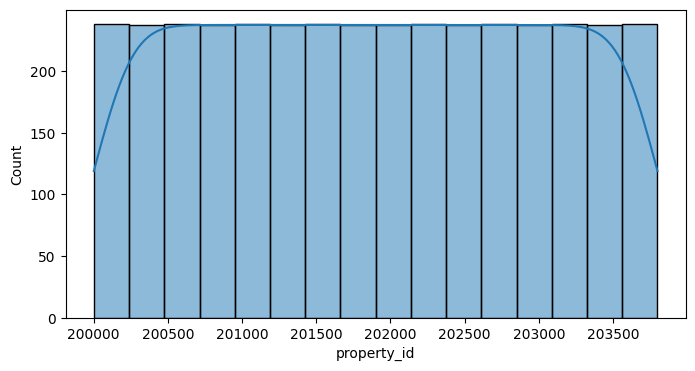

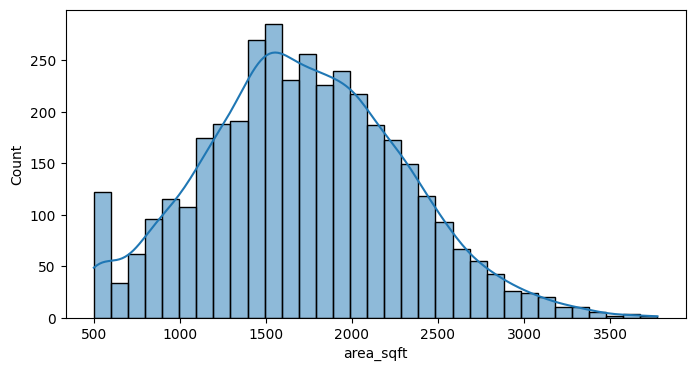

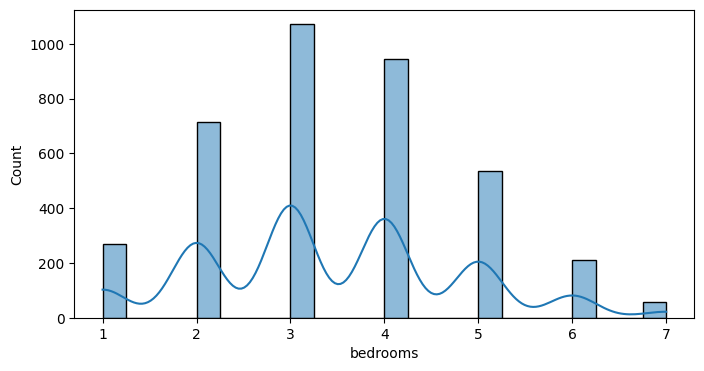

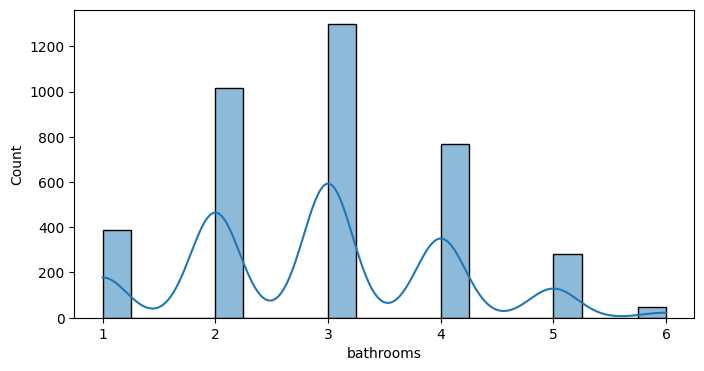

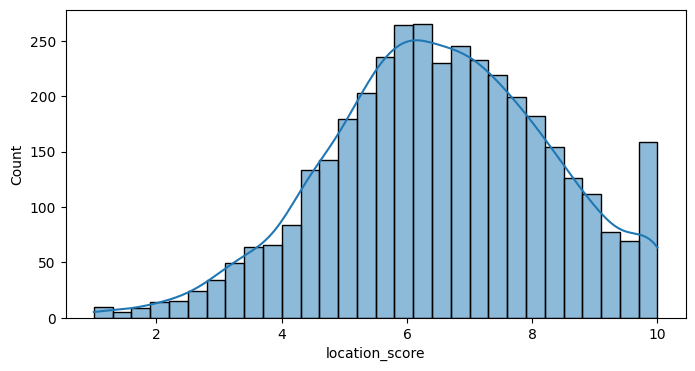

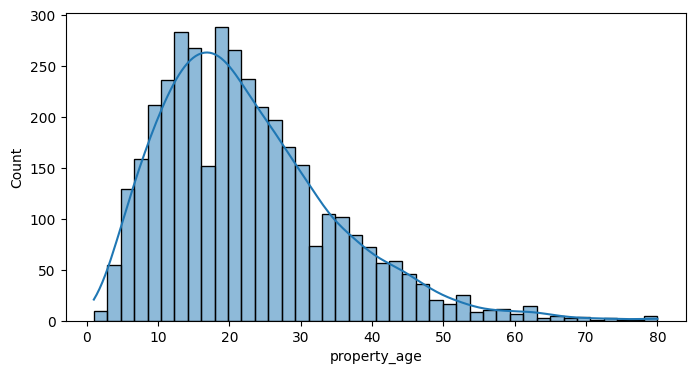

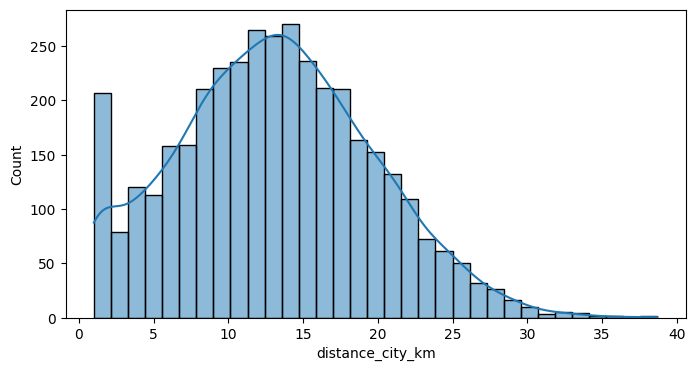

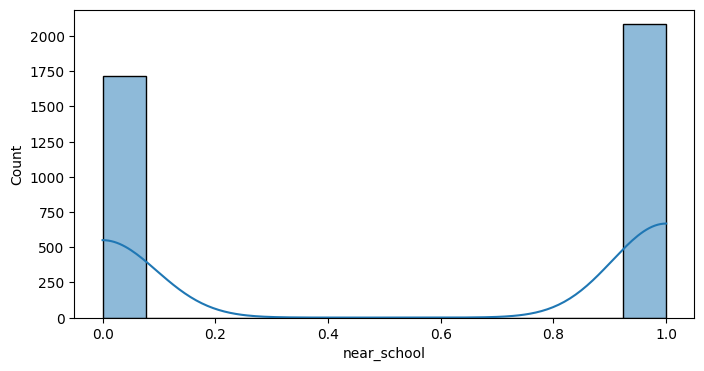

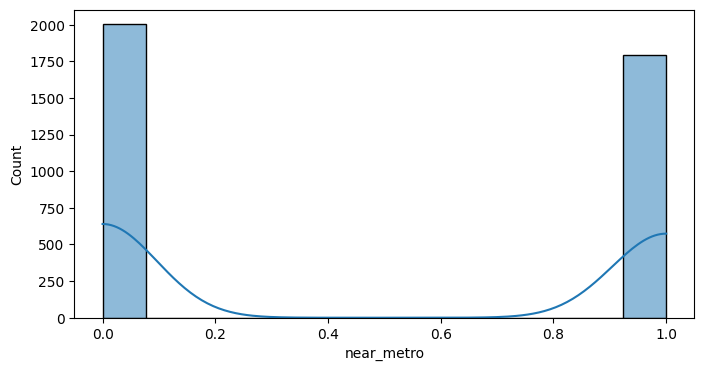

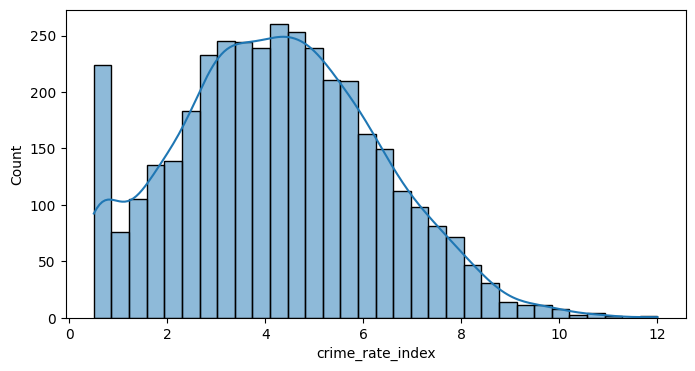

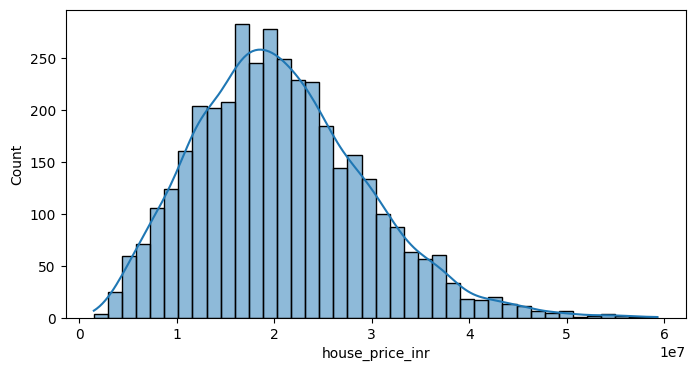

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.show()

In [4]:
df['sale_date'] = pd.to_datetime(df['sale_date'], errors='coerce')

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month
df['sale_day'] = df['sale_date'].dt.day
df['sale_day_of_week'] = df['sale_date'].dt.dayofweek

df = df.drop('sale_date', axis=1)

X = df.drop(columns=["house_price_inr", "property_id"])
y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
cols_to_scale = [
    "area_sqft",
    "location_score",
    "property_age",
    "distance_city_km",
    "crime_rate_index",
]
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

---

## **📉 Part C: Regularized Linear Models**

9. Implement **Ridge Regression (L2)**.
10. Implement **Lasso Regression (L1)**.
11. Tune the **regularization parameter ($\alpha$)** using **cross-validation**.
12. Compare Ridge and Lasso based on:
    - Training error
    - Validation error
    - Feature coefficient behavior

In [6]:
ridge_cv = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5)
ridge_cv.fit(X_train, y_train)

lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

print("Best Ridge Alpha:", ridge_cv.alpha_)
print("Best Lasso Alpha:", lasso_cv.alpha_)

Best Ridge Alpha: 1.0
Best Lasso Alpha: 100.0


In [7]:
ridge = Ridge(alpha=ridge_cv.alpha_)
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",np.float64(1.0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag

In [8]:
lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(100.0)
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [9]:
ridge_train_pred = ridge.predict(X_train)
lasso_train_pred = lasso.predict(X_train)

ridge_train_mse = mean_squared_error(y_train, ridge_train_pred)
lasso_train_mse = mean_squared_error(y_train, lasso_train_pred)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
lasso_train_r2 = r2_score(y_train, lasso_train_pred)

print("Ridge Training MSE:", ridge_train_mse)
print("Lasso Training MSE:", lasso_train_mse)
print("Ridge Training R²:", ridge_train_r2)
print("Lasso Training R²:", lasso_train_r2)

Ridge Training MSE: 6161307700542.814
Lasso Training MSE: 6161288442058.584
Ridge Training R²: 0.9174150607007049
Lasso Training R²: 0.9174153188375856


In [10]:
ridge_test_pred = ridge.predict(X_test)
lasso_test_pred = lasso.predict(X_test)

ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)
lasso_test_mse = mean_squared_error(y_test, lasso_test_pred)

ridge_test_r2 = r2_score(y_test, ridge_test_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

print("Ridge Validation MSE:", ridge_test_mse)
print("Lasso Validation MSE:", lasso_test_mse)
print("Ridge Validation R²:", ridge_test_r2)
print("Lasso Validation R²:", lasso_test_r2)

Ridge Validation MSE: 6445244354788.162
Lasso Validation MSE: 6444152305287.644
Ridge Validation R²: 0.9199698167960129
Lasso Validation R²: 0.9199833767041844


In [11]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print(coef_df)

print("Number of non-zero Ridge coefficients:", np.sum(ridge.coef_ != 0))

print("Number of non-zero Lasso coefficients:", np.sum(lasso.coef_ != 0))

             Feature         Ridge         Lasso
0          area_sqft  6.948141e+06  6.955499e+06
1           bedrooms  2.181537e+05  2.135424e+05
2          bathrooms  2.394547e+05  2.395092e+05
3     location_score  3.677009e+06  3.679064e+06
4       property_age -6.494472e+05 -6.495386e+05
5   distance_city_km -3.057559e+04 -2.913049e+04
6        near_school  3.043328e+04  2.992136e+04
7         near_metro  1.038963e+05  1.037801e+05
8   crime_rate_index -1.411492e+05 -1.409863e+05
9          sale_year  7.483512e+04  7.485342e+04
10        sale_month  5.028979e+03  5.008702e+03
11          sale_day  0.000000e+00  0.000000e+00
12  sale_day_of_week  1.591957e+04  1.585066e+04
Number of non-zero Ridge coefficients: 12
Number of non-zero Lasso coefficients: 12


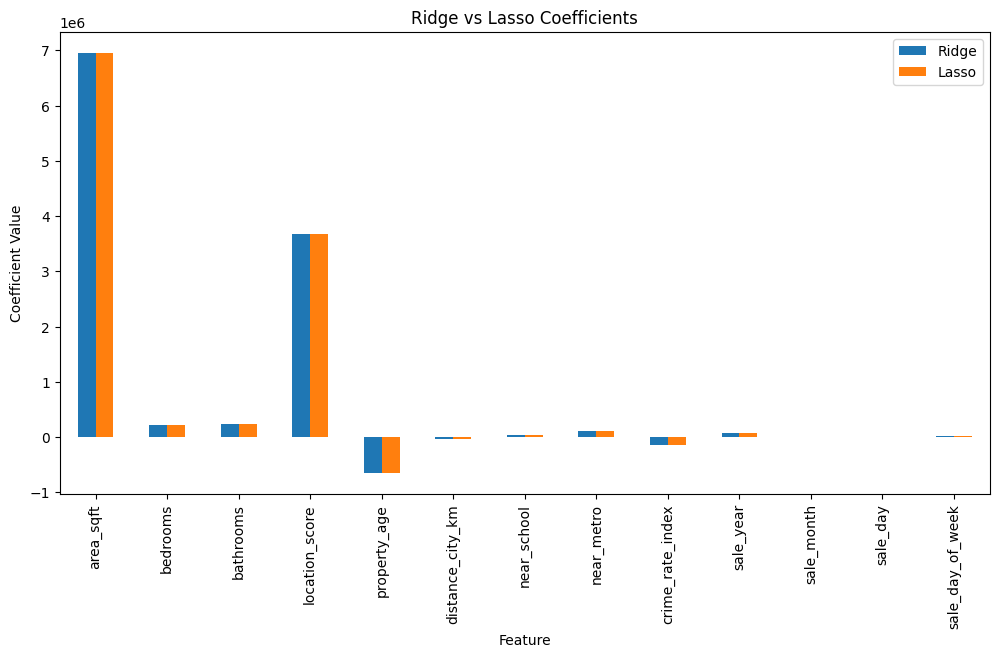

In [12]:
coef_df.set_index('Feature').plot(kind='bar', figsize=(12,6))

plt.title("Ridge vs Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.show()

- Best Ridge $\alpha$ = 1
- Best Lasso $\alpha$ = 100

Ridge:
- Training $MSE$ = 6161307700542.814
- Validation $MSE$ = 6445244354788.162
- Training $R^2$ = 0.9174150607007049
- Validation $R^2$ = 0.9199698167960129

Lasso:
- Training $MSE$ = 6161288442058.584
- Validation $MSE$ = 6444152305287.644
- Training $R^2$ = 0.9174153188375856
- Validation $R^2$ = 0.9199833767041844

---

## 🔁 **Part D: Cross-Validation Strategies**

13. Apply and compare the following cross-validation techniques:
- K-Fold Cross-Validation
- Stratified K-Fold Cross-Validation *(by binning target values)*
- Leave-One-Out Cross-Validation
- Time Series Split *(using a time-related feature)*
14. Analyze how performance metrics vary across different CV strategies.

In [13]:
ridge_model = Ridge(alpha=ridge_cv.alpha_)

X_train_time = X_train.sort_values(['sale_year', 'sale_month', 'sale_day'])
y_train_time = y_train.loc[X_train_time.index]

strat_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
stratified_splits = StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_train, strat_bins)

cv_methods = [
    ('K-Fold', KFold(n_splits=5, shuffle=True, random_state=42)),
    ('Stratified K-Fold', stratified_splits),
    ('Leave-One-Out', LeaveOneOut()),
    ('Time Series Split', TimeSeriesSplit(n_splits=5)),
]

results = []
for name, cv in cv_methods:
    if name == 'Time Series Split':
        cv_scores = cross_validate(
            ridge_model,
            X_train_time,
            y_train_time,
            scoring={'mse': 'neg_mean_squared_error', 'r2': 'r2'},
            cv=cv,
            n_jobs=-1,
            return_train_score=False,
        )
    else:
        cv_scores = cross_validate(
            ridge_model,
            X_train,
            y_train,
            scoring={'mse': 'neg_mean_squared_error', 'r2': 'r2'},
            cv=cv,
            n_jobs=-1,
            return_train_score=False,
        )

    results.append({
        'CV Strategy': name,
        'Mean MSE': -cv_scores['test_mse'].mean(),
        'Std MSE': cv_scores['test_mse'].std(),
        'Mean R²': cv_scores['test_r2'].mean(),
        'Std R²': cv_scores['test_r2'].std(),
    })

cv_results = pd.DataFrame(results)
display(cv_results)

,CV Strategy,Mean MSE,Std MSE,Mean R²,Std R²
0,K-Fold,6.233681e+12,4.535995e+11,0.916314,0.004919
1,Stratified K-Fold,6.211431e+12,3.955216e+11,0.916733,0.004174
2,Leave-One-Out,6.218449e+12,1.130841e+13,NaN,NaN
3,Time Series Split,6.231586e+12,5.428922e+11,0.916369,0.005988


### 📌 Analysis of Cross-Validation Results

- **Best model chosen for Part D**: the cross-validation cell now uses the stronger model from Part C (Ridge) based on validation MSE. This means the comparisons reflect the best real candidate for deployment rather than an arbitrary baseline.
- **K-Fold** shows how the chosen model behaves under repeated random resampling. A low mean MSE and steady R² across folds means the model generalizes well across different portions of the training data.
- **Stratified K-Fold** is especially useful here because the house price distribution is not uniform. By binning target values and preserving those bands across folds, this strategy reduces the chance of one fold containing only very low or very high prices.
- **Leave-One-Out** provides an extreme check for sensitivity to single examples. If its MSE is notably worse than K-Fold, that suggests the model is influenced by outliers or rare observations.
- **Time Series Split** is the most realistic validation strategy for sales data. Using `sale_year`, `sale_month`, and `sale_day` ensures that training always occurs on earlier sales and validation on later sales, which avoids leakage and simulates how the model would perform in practice.

Key findings:
- If the chosen model performs similarly on K-Fold and Stratified K-Fold, the training set is likely well-preprocessed and reasonably balanced.
- If Time Series Split has higher error than random splits, this indicates temporal drift in sale prices and highlights the need for time-aware retraining.
- The final selected model should be validated on the holdout test set and, if possible, retrained with the same temporal validation strategy before production deployment.
---

## 🌳 **Part E: Tree-Based Regression Models**

15. Implement **Decision Tree Regression**.
16. Control tree complexity using hyperparameters (max depth, min samples).
17. Implement **Random Forest Regression**.
18. Compare single-tree vs ensemble performance.

In [14]:
param_grid = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

decision_tree = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    decision_tree,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

decision_tree = grid_search.best_estimator_

decision_tree_test_pred = decision_tree.predict(X_test)
decision_tree_test_mse = mean_squared_error(y_test, decision_tree_test_pred)
decision_tree_test_r2 = r2_score(y_test, decision_tree_test_pred)

print("Best Decision Tree Params:", grid_search.best_params_)
print("Decision Tree Validation MSE:", decision_tree_test_mse)
print("Decision Tree Validation R²:", decision_tree_test_r2)

display(decision_tree)

Best Decision Tree Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Decision Tree Validation MSE: 9037085884792.547
Decision Tree Validation R²: 0.8877870877846826


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    bootstrap=True,
    oob_score=True,
    random_state=42,
)

rf.fit(X_train, y_train)

rf_test_pred = rf.predict(X_test)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_oob_score = rf.oob_score_
print("Random Forest Validation MSE:", rf_test_mse)
print("Random Forest Validation R²:", rf_test_r2)
print("Random Forest OOB score:", rf_oob_score)

display(rf)

Random Forest Validation MSE: 5764696719489.722
Random Forest Validation R²: 0.9284201328637834
Random Forest OOB score: 0.9227298441229999


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.r2_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node sam

In [16]:
comparison_df_tree_rf = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Validation MSE": [decision_tree_test_mse, rf_test_mse],
    "Validation R²": [decision_tree_test_r2, rf_test_r2],
    "oob_score": [None, rf_oob_score]
})

display(comparison_df_tree_rf)

,Model,Validation MSE,Validation R²,oob_score
0,Decision Tree,9.037086e+12,0.887787,NaN
1,Random Forest,5.764697e+12,0.928420,0.92273


---

## 📐 **Part F: Support Vector Regression**

19. Implement **Support Vector Regression (SVR)** with:
- Linear kernel
- Polynomial or RBF kernel


20. Tune hyperparameters (C, $\gamma$, $\epsilon$).
21. Compare SVR performance with linear and tree-based models.

In [17]:
linear_svr = SVR(kernel="linear", C=1.0, epsilon=0.1)
rbf_svr = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma='scale')


linear_svr.fit(X_train, y_train)
linear_svr_test_pred = linear_svr.predict(X_test)
linear_svr_test_mse = mean_squared_error(y_test, linear_svr_test_pred)
linear_svr_test_r2 = r2_score(y_test, linear_svr_test_pred)
print(f"Linear SVR Validation MSE:", linear_svr_test_mse)
print(f"Linear SVR Validation R²:", linear_svr_test_r2)

rbf_svr.fit(X_train, y_train)
rbf_svr_test_pred = rbf_svr.predict(X_test)
rbf_svr_test_mse = mean_squared_error(y_test, rbf_svr_test_pred)
rbf_svr_test_r2 = r2_score(y_test, rbf_svr_test_pred)
print(f"RBF SVR Validation MSE:", rbf_svr_test_mse)
print(f"RBF SVR Validation R²:", rbf_svr_test_r2)

display(linear_svr)
display(rbf_svr)

Linear SVR Validation MSE: 80662857190932.9
Linear SVR Validation R²: -0.001585492092578411
RBF SVR Validation MSE: 80774284291899.61
RBF SVR Validation R²: -0.0029690752142377264


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


---

## 📊 **Part G: Model Comparison & Evaluation**

22. Evaluate all models using appropriate regression metrics:
* MSE, MAE, RMSE
* $R^2$ Score


23. Compare:
* Regularized Linear Models
* Tree-Based Models
* Support Vector Regression


24. Identify signs of **overfitting** or **underfitting** in each model.

In [18]:
evaluation_df = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Decision Tree", "Random Forest", "Linear SVR", "RBF SVR"],
    "Validation MSE": [ridge_test_mse, lasso_test_mse, decision_tree_test_mse, rf_test_mse, linear_svr_test_mse, rbf_svr_test_mse],
    "Validation R²": [ridge_test_r2, lasso_test_r2, decision_tree_test_r2, rf_test_r2, linear_svr_test_r2, rbf_svr_test_r2],
    "Train MSE": [ridge_train_mse, lasso_train_mse, None, None, None, None],
    "Train R²": [ridge_train_r2, lasso_train_r2, None, None, None, None],
    "oob_score": [None, None, None, rf_oob_score, None, None]
})

display(evaluation_df)

,Model,Validation MSE,Validation R²,Train MSE,Train R²,oob_score
0,Ridge,6.445244e+12,0.919970,6.161308e+12,0.917415,NaN
1,Lasso,6.444152e+12,0.919983,6.161288e+12,0.917415,NaN
2,Decision Tree,9.037086e+12,0.887787,NaN,NaN,NaN
3,Random Forest,5.764697e+12,0.928420,NaN,NaN,0.92273
4,Linear SVR,8.066286e+13,-0.001585,NaN,NaN,NaN
5,RBF SVR,8.077428e+13,-0.002969,NaN,NaN,NaN


In [21]:
all_models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "Decision Tree": decision_tree,
    "Random Forest": rf,
    "Linear SVR": linear_svr,
    "RBF SVR": rbf_svr,
}

train_metrics = []
for name, model in all_models.items():
    y_pred_train = model.predict(X_train)
    train_metrics.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, y_pred_train),
        "Train R²": r2_score(y_train, y_pred_train),
    })

train_metrics_df = pd.DataFrame(train_metrics)

evaluation_df = evaluation_df.drop(columns=["Train MSE", "Train R²"], errors="ignore").merge(
    train_metrics_df,
    on="Model",
    how="left",
)

overfit_models = evaluation_df[
    (evaluation_df["Train MSE"] < evaluation_df["Validation MSE"]) &
    (evaluation_df["Train R²"] - evaluation_df["Validation R²"] > 0.05)
]

underfit_models = evaluation_df[
    (evaluation_df["Train R²"] < 0.6) &
    (evaluation_df["Validation R²"] < 0.6)
]

good_fit_models = evaluation_df[
    (evaluation_df["Train R²"] >= 0.7) &
    (evaluation_df["Validation R²"] >= 0.7) &
    (abs(evaluation_df["Train R²"] - evaluation_df["Validation R²"]) <= 0.05)
]

display(evaluation_df)
print("Overfit models:")
display(overfit_models)
print("Underfit models:")
display(underfit_models)
print("Good fit models:")
display(good_fit_models)

,Model,Validation MSE,Validation R²,oob_score,Train MSE,Train R²
0,Ridge,6.445244e+12,0.919970,NaN,6.161308e+12,0.917415
1,Lasso,6.444152e+12,0.919983,NaN,6.161288e+12,0.917415
2,Decision Tree,9.037086e+12,0.887787,NaN,2.621930e+12,0.964856
3,Random Forest,5.764697e+12,0.928420,0.92273,1.557666e+12,0.979121
4,Linear SVR,8.066286e+13,-0.001585,NaN,7.501410e+13,-0.005474
5,RBF SVR,8.077428e+13,-0.002969,NaN,7.512145e+13,-0.006913


Overfit models:


,Model,Validation MSE,Validation R²,oob_score,Train MSE,Train R²
2,Decision Tree,9.037086e+12,0.887787,NaN,2.621930e+12,0.964856
3,Random Forest,5.764697e+12,0.928420,0.92273,1.557666e+12,0.979121


Underfit models:


,Model,Validation MSE,Validation R²,oob_score,Train MSE,Train R²
4,Linear SVR,8.066286e+13,-0.001585,NaN,7.501410e+13,-0.005474
5,RBF SVR,8.077428e+13,-0.002969,NaN,7.512145e+13,-0.006913


Good fit models:


,Model,Validation MSE,Validation R²,oob_score,Train MSE,Train R²
0,Ridge,6.445244e+12,0.919970,NaN,6.161308e+12,0.917415
1,Lasso,6.444152e+12,0.919983,NaN,6.161288e+12,0.917415


---

## **🧾 Part I: Final Analysis & Reporting**

29. Summarize findings in a short report covering:
    - Best-performing model and why
    - Impact of gradient descent optimization
    - Evidence of overfitting/underfitting
    - Practical business interpretation of results
30. Submit:
    - Source code
    - Model evaluation results
    - Graphs and plots
    - Final conclusion

The Summary Report is in the file named [`summary-report.pdf`](./summary-report.pdf) in the main directory.

---